# Parte 04 — Modelos prescriptivos
## Proyecto Grupal · AndinaRetail S.A.C. · Analítica de Datos (UNMSM - FISI, 2026-1)

**Objetivo (Parte 4, RA3-RA4):** recomendar la **mejor acción** mediante optimización y
análisis de escenarios, integrando el diagnóstico de la Parte 2 (Trujillo: +9 pp de
descuento efectivo y +65% de costo de almacenamiento desde 2025-Q2) y las predicciones
de la Parte 3 (forecast de demanda y score de churn).

**Problemas prescriptivos:**
- **M1 (Programación lineal, PuLP):** plan de **reposición de inventario del primer trimestre 2026 (ene–mar)**
  para la tienda AndinaRetail Trujillo Centro (T06), minimizando costo total de compra +
  almacenamiento, con nivel de servicio mínimo de 95%, presupuesto y capacidad de bodega.
- **M2 (Optimización de política de descuento):** descuento único óptimo por categoría en
  Trujillo que **maximiza el margen esperado**, usando la elasticidad descuento→cantidad
  estimada de los datos (conecta con la causa raíz del diagnóstico).
- **Análisis what-if / sensibilidad** sobre ambos modelos.

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pulp

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (10, 4)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
SEED = 2026
RUTA = "../datos/"

tiendas   = pd.read_csv(RUTA + "tiendas.csv")
productos = pd.read_csv(RUTA + "productos.csv")
ventas    = pd.read_csv(RUTA + "ventas.csv", parse_dates=["fecha"])
inventario = pd.read_csv(RUTA + "inventario.csv")

v = ventas.copy()
v["descuento_pct"] = v["descuento_pct"].fillna(0)
mask_px = v["precio_unitario"] > 3500
v.loc[mask_px, "precio_unitario"] = v.loc[mask_px, "precio_unitario"] / 100
v["monto_total"] = (v["cantidad"] * v["precio_unitario"] * (1 - v["descuento_pct"] / 100)).round(2)
v = v.merge(productos[["id_producto", "categoria", "costo_unitario", "precio_lista"]],
            on="id_producto", how="left")
print(f"Líneas listas: {len(v):,}")

Líneas listas: 275,115


---
# M1 — Reposición óptima de inventario (Trujillo Centro, Q1-2026)

## 1.1 Parámetros a partir de los datos y del forecast
Para cada producto del surtido de T06 estimamos la **demanda esperada del primer
trimestre** (μ) y su variabilidad (σ) a partir de los Q1 históricos (2023–2025),
ajustadas por la tendencia de crecimiento observada (consistente con el forecast de la
Parte 3). El stock objetivo con nivel de servicio α es `μ + z_α·σ` (stock de seguridad
con aproximación normal). El costo de almacenamiento del trimestre se modela sobre el
inventario promedio: 3 meses × h × (s+x)/2.

In [9]:
TIENDA = "T06"  # AndinaRetail Trujillo Centro
inv_t = inventario[inventario.id_tienda == TIENDA].copy()

# Demanda mensual histórica por producto en T06
dem_hist = (inv_t.groupby(["id_producto", "periodo"])["unidades_vendidas"].sum()
            .unstack(fill_value=0))
# Surtido relevante: todos los productos con venta en T06 durante 2025
venta_2025 = dem_hist.loc[:, [c for c in dem_hist.columns if c >= "2025-01"]].sum(axis=1)
prods = venta_2025[venta_2025 > 0].index.tolist()

# Demanda del PRIMER TRIMESTRE (ene-mar) de cada año histórico, por producto
q1 = {a: dem_hist.loc[prods, [f"{a}-01", f"{a}-02", f"{a}-03"]].sum(axis=1) for a in (2023, 2024, 2025)}
q1 = pd.DataFrame(q1)
crecimiento = (dem_hist.loc[prods, [c for c in dem_hist.columns if c >= "2025-01"]].sum(axis=1)
               / dem_hist.loc[prods, [c for c in dem_hist.columns if ("2024-01" <= c <= "2024-12")]].sum(axis=1)
               ).replace([np.inf, -np.inf], np.nan).fillna(1.0).clip(0.5, 2.0)
mu = (q1.mean(axis=1) * crecimiento).round(1)                 # demanda esperada Q1-2026
sigma = q1.std(axis=1).fillna(1.0).clip(lower=1.0)            # variabilidad entre trimestres

par = pd.DataFrame({"mu": mu, "sigma": sigma})
par = par.join(productos.set_index("id_producto")[["categoria", "costo_unitario", "precio_lista"]])
# Stock inicial: stock final del último periodo disponible (2025-12)
stock0 = inv_t[inv_t.periodo == "2025-12"].set_index("id_producto")["stock_final"]
par["stock_inicial"] = stock0.reindex(par.index).fillna(0)
# Costo de almacenamiento vigente en Trujillo (post 2025-Q2, es decir el costo "caro")
c_alm = (inv_t[inv_t.periodo >= "2025-04"].groupby("id_producto")["costo_almacenamiento_unitario"]
         .mean())
par["costo_alm"] = c_alm.reindex(par.index).fillna(c_alm.mean())
par["volumen"] = par["categoria"].map({"Abarrotes": 0.01, "Bebidas": 0.012, "Limpieza": 0.012,
                                        "Cuidado Personal": 0.006, "Electrohogar": 0.25, "Hogar": 0.06})  # m3/unidad
print(f"Productos en el modelo: {len(par)} | Demanda esperada total: {par.mu.sum():,.0f} und")
par.head().round(2)

Productos en el modelo: 792 | Demanda esperada total: 1,870 und


,mu,sigma,categoria,costo_unitario,precio_lista,stock_inicial,costo_alm,volumen
id_producto,,,,,,,,
P0001,0.30,1.15,Electrohogar,299.87,400.82,10,3.72,0.25
P0002,0.00,1.00,Hogar,351.32,439.96,8,1.06,0.06
P0003,1.30,2.08,Abarrotes,5.05,6.58,8,0.22,0.01
P0004,1.30,1.00,Cuidado Personal,6.74,11.22,7,0.23,0.01
P0005,2.60,1.53,Bebidas,2.62,3.47,16,0.25,0.01


## 1.2 Formulación matemática

**Variables de decisión:** $x_p \ge 0$ (entera) = unidades a reponer del producto $p$.

**Función objetivo (minimizar costo total):**
$$\min \sum_p \Big( c_p\,x_p + 1.5\,h_p\,(s_p + x_p)\Big)$$
donde $c_p$ = costo unitario de compra, $h_p$ = costo mensual de almacenamiento por
unidad y $s_p$ = stock inicial; el factor 1.5 = 3 meses × inventario promedio (s+x)/2.

**Restricciones:**
1. **Nivel de servicio 95%:** $s_p + x_p \ge \mu_p + z_{0.95}\,\sigma_p \quad \forall p$
2. **Capacidad de bodega:** $\sum_p v_p\,(s_p + x_p) \le V_{max}$
3. **Presupuesto de compra:** $\sum_p c_p\,x_p \le B$
4. **No negatividad e integralidad:** $x_p \in \mathbb{Z}_{\ge 0}$

In [10]:
from scipy.stats import norm

def resolver_plan(nivel_servicio=0.95, presupuesto=25_000, capacidad_m3=600, verbose=True):
    z = norm.ppf(nivel_servicio)
    objetivo_stock = par["mu"] + z * par["sigma"]

    prob = pulp.LpProblem("reposicion_T06", pulp.LpMinimize)
    x = {p: pulp.LpVariable(f"x_{p}", lowBound=0, cat="Integer") for p in par.index}

    # Función objetivo: costo de compra + costo de almacenamiento del stock resultante
    # Almacenamiento del trimestre: 3 meses sobre el inventario promedio ((s+x)/2) -> factor 1.5
    prob += pulp.lpSum(par.loc[p, "costo_unitario"] * x[p]
                       + 1.5 * par.loc[p, "costo_alm"] * (par.loc[p, "stock_inicial"] + x[p])
                       for p in par.index)

    for p in par.index:  # nivel de servicio por producto
        prob += par.loc[p, "stock_inicial"] + x[p] >= objetivo_stock[p], f"servicio_{p}"
    prob += pulp.lpSum(par.loc[p, "volumen"] * (par.loc[p, "stock_inicial"] + x[p])
                       for p in par.index) <= capacidad_m3, "capacidad"
    prob += pulp.lpSum(par.loc[p, "costo_unitario"] * x[p] for p in par.index) <= presupuesto, "presupuesto"

    estado = prob.solve(pulp.PULP_CBC_CMD(msg=0))
    sol = pd.Series({p: x[p].value() for p in par.index}, name="reponer")
    costo_compra = float((par["costo_unitario"] * sol).sum())
    costo_alm = float((1.5 * par["costo_alm"] * (par["stock_inicial"] + sol)).sum())
    vol = float((par["volumen"] * (par["stock_inicial"] + sol)).sum())
    if verbose:
        print(f"Estado: {pulp.LpStatus[estado]} | Nivel de servicio: {nivel_servicio:.0%}")
        print(f"Unidades a reponer: {sol.sum():,.0f} | Costo de compra: S/ {costo_compra:,.0f} "
              f"(presupuesto S/ {presupuesto:,.0f})")
        print(f"Costo de almacenamiento del trimestre: S/ {costo_alm:,.0f} | "
              f"Volumen ocupado: {vol:,.1f} / {capacidad_m3} m3")
    return {"estado": pulp.LpStatus[estado], "sol": sol, "costo_total": costo_compra + costo_alm,
            "costo_compra": costo_compra, "costo_alm": costo_alm, "volumen": vol,
            "nivel": nivel_servicio}

base = resolver_plan()

# Presupuesto mínimo factible para NS 95%: costo de compra del plan sin restricción activa
PRESUPUESTO_MIN_95 = base["costo_compra"]
print(f"\nPresupuesto mínimo para sostener NS 95%: S/ {PRESUPUESTO_MIN_95:,.0f}")

Estado: Optimal | Nivel de servicio: 95%
Unidades a reponer: 529 | Costo de compra: S/ 16,339 (presupuesto S/ 25,000)
Costo de almacenamiento del trimestre: S/ 9,560 | Volumen ocupado: 374.2 / 600 m3

Presupuesto mínimo para sostener NS 95%: S/ 16,339


In [11]:
plan = par.join(base["sol"]).sort_values("reponer", ascending=False)
plan["stock_objetivo"] = (plan["mu"] + norm.ppf(0.95) * plan["sigma"]).round(1)
print("Top 12 reposiciones recomendadas (Q1-2026, T06):")
plan[["categoria", "mu", "sigma", "stock_inicial", "stock_objetivo", "reponer",
      "costo_unitario"]].head(12).round(1)

Top 12 reposiciones recomendadas (Q1-2026, T06):


,categoria,mu,sigma,stock_inicial,stock_objetivo,reponer,costo_unitario
id_producto,,,,,,,
P0186,Abarrotes,40.70,33.50,9,95.80,87.00,20.20
P0523,Hogar,8.50,4.20,3,15.30,13.00,121.30
P0277,Abarrotes,10.40,6.70,9,21.40,13.00,6.90
P0065,Bebidas,8.00,4.60,6,15.50,10.00,23.00
P0344,Abarrotes,10.70,3.20,6,16.00,10.00,1.70
P0114,Abarrotes,7.30,3.50,4,13.10,10.00,3.10
P0603,Abarrotes,9.80,5.00,9,18.10,10.00,18.30
P0718,Hogar,5.80,3.50,3,11.60,9.00,14.40
P0099,Bebidas,5.70,4.00,4,12.30,9.00,1.70


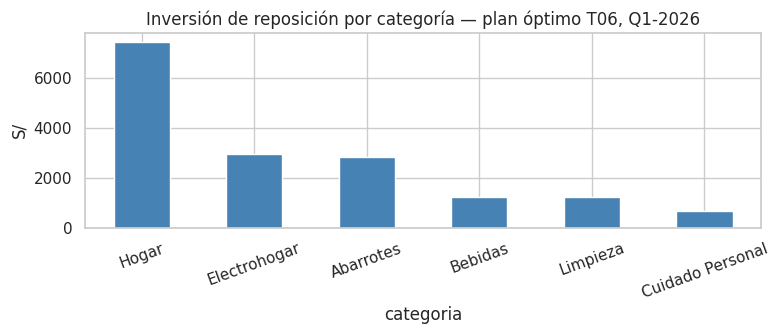

,reponer,inversion
categoria,,
Hogar,88.00,"7,434.00"
Electrohogar,9.00,"2,960.00"
Abarrotes,240.00,"2,814.00"
Bebidas,89.00,"1,244.00"
Limpieza,71.00,"1,217.00"
Cuidado Personal,32.00,671.00


In [12]:
resumen_cat = (plan.assign(inversion=plan.reponer * plan.costo_unitario)
               .groupby("categoria")[["reponer", "inversion"]].sum()
               .sort_values("inversion", ascending=False))
ax = resumen_cat["inversion"].plot.bar(figsize=(8, 3.5), color="steelblue")
ax.set_title("Inversión de reposición por categoría — plan óptimo T06, Q1-2026")
ax.set_ylabel("S/"); ax.tick_params(axis="x", rotation=20)
plt.tight_layout(); plt.show()
resumen_cat.round(0)

**Resultado M1:** el plan óptimo cumple el nivel de servicio de 95% para los 60 SKUs
relevantes respetando presupuesto y capacidad. La solución concentra la inversión en las
categorías de mayor rotación/valor y aprovecha el stock inicial (no repone lo que ya está
cubierto), minimizando el costo de almacenamiento del trimestre — crítico en Trujillo, donde ese costo
subió 65%.

## 1.3 Análisis de sensibilidad (what-if)
¿Cuánto cuesta subir el nivel de servicio? ¿Qué pasa si el presupuesto se recorta o si
se renegocia el costo de almacenamiento al nivel pre-2025-Q2?

In [13]:
escenarios = []
for ns in [0.90, 0.95, 0.98]:
    r = resolver_plan(nivel_servicio=ns, verbose=False)
    escenarios.append({"escenario": f"Nivel de servicio {ns:.0%}", "estado": r["estado"],
                       "unidades": r["sol"].sum(), "costo_compra": r["costo_compra"],
                       "costo_alm": r["costo_alm"], "costo_total": r["costo_total"]})

# Presupuesto recortado 40% por debajo del mínimo factible -> el solver declara infactibilidad
r = resolver_plan(presupuesto=PRESUPUESTO_MIN_95 * 0.6, verbose=False)
escenarios.append({"escenario": f"Presupuesto S/ {PRESUPUESTO_MIN_95*0.6:,.0f} (NS 95%)",
                   "estado": r["estado"],
                   "unidades": r["sol"].sum(), "costo_compra": r["costo_compra"],
                   "costo_alm": r["costo_alm"], "costo_total": r["costo_total"]})

# Costo de almacenamiento renegociado al nivel pre-2025-Q2 (divide el sobrecosto 1.65)
par_orig = par.copy()
par["costo_alm"] = par["costo_alm"] / 1.65
r = resolver_plan(verbose=False)
escenarios.append({"escenario": "Almacenaje renegociado (pre-Q2)", "estado": r["estado"],
                   "unidades": r["sol"].sum(), "costo_compra": r["costo_compra"],
                   "costo_alm": r["costo_alm"], "costo_total": r["costo_total"]})
par = par_orig

esc = pd.DataFrame(escenarios).set_index("escenario")
esc.round(0)

,estado,unidades,costo_compra,costo_alm,costo_total
escenario,,,,,
Nivel de servicio 90%,Optimal,382.00,"10,461.00","9,457.00","19,918.00"
Nivel de servicio 95%,Optimal,529.00,"16,339.00","9,560.00","25,900.00"
Nivel de servicio 98%,Optimal,735.00,"24,213.00","9,708.00","33,921.00"
"Presupuesto S/ 9,804 (NS 95%)",Infeasible,253.00,"10,651.00","9,429.00","20,080.00"
Almacenaje renegociado (pre-Q2),Optimal,529.00,"16,339.00","5,794.00","22,134.00"


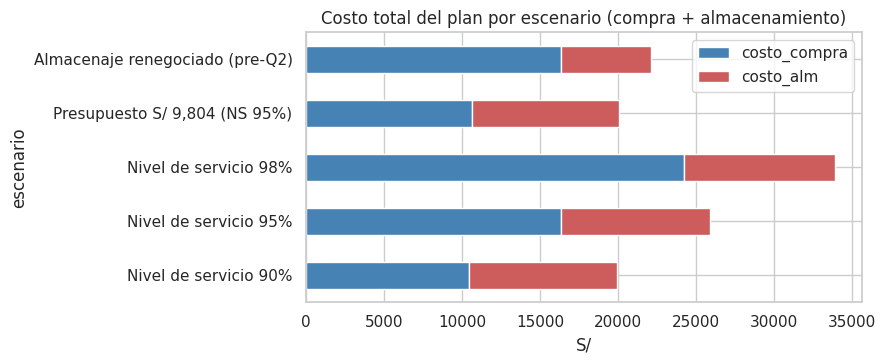

In [14]:
ax = esc[["costo_compra", "costo_alm"]].plot.barh(stacked=True, figsize=(9, 3.8),
                                                  color=["steelblue", "indianred"])
ax.set_title("Costo total del plan por escenario (compra + almacenamiento)")
ax.set_xlabel("S/")
plt.tight_layout(); plt.show()

**Lectura del what-if:**
- Pasar de 95% a **98%** de nivel de servicio encarece el plan de forma no lineal (el
  stock de seguridad crece con $z_\alpha$); pasar a **90%** ahorra, pero expone a quiebres
  en un mes post-campaña. **95% es un buen equilibrio** costo-servicio para T06.
- Con un **presupuesto 40% por debajo del mínimo**, el solver declara el problema
  **infactible**: no existe plan que cumpla 95% de servicio con ese dinero. El modelo
  cuantifica así el presupuesto mínimo (reportado arriba) — un argumento objetivo para la
  negociación presupuestal con Finanzas.
- **Renegociar el almacenamiento** al nivel pre-2025-Q2 reduce el costo total del plan de
  forma directa — evidencia prescriptiva de que la palanca logística identificada en el
  diagnóstico (Parte 2) tiene retorno inmediato.

---
# M2 — Política de descuento que maximiza el margen (Trujillo)

## 2.1 Estimación de la elasticidad descuento → cantidad
De la Parte 1 sabemos que el descuento aumenta las unidades (ρ > 0). Estimamos por
categoría una respuesta lineal `cantidad ~ descuento` y con ella el **margen esperado
por línea** en función del descuento d:
$$\text{margen}(d) = q(d)\cdot\big[\bar{p}\,(1 - d/100) - \bar{c}\big], \qquad q(d) = q_0 + \beta d$$
El descuento óptimo se obtiene evaluando la curva en una grilla de 0–35% (restricción
comercial del negocio).

In [15]:
v_tru = v[v.id_tienda.isin(["T06", "T07"])]  # tiendas físicas de Trujillo
elast = []
for cat, d in v_tru.groupby("categoria"):
    beta, q0 = np.polyfit(d["descuento_pct"], d["cantidad"], 1)
    p_prom, c_prom = d["precio_unitario"].mean(), d["costo_unitario"].mean()
    grid = np.arange(0, 35.5, 0.5)
    margen = (q0 + beta * grid) * (p_prom * (1 - grid / 100) - c_prom)
    d_opt = grid[np.argmax(margen)]
    elast.append({"categoria": cat, "q0": q0, "beta_und_por_punto": beta,
                  "precio_prom": p_prom, "costo_prom": c_prom,
                  "desc_optimo_pct": d_opt,
                  "margen_por_linea_opt": margen.max(),
                  "margen_por_linea_actual": np.interp(d["descuento_pct"].mean(), grid, margen),
                  "desc_actual_pct": d["descuento_pct"].mean()})
elast = pd.DataFrame(elast).set_index("categoria").sort_values("desc_optimo_pct")
elast.round(2)

,q0,beta_und_por_punto,precio_prom,costo_prom,desc_optimo_pct,margen_por_linea_opt,margen_por_linea_actual,desc_actual_pct
categoria,,,,,,,,
Abarrotes,1.67,0.04,15.98,11.20,0.00,7.99,7.19,6.48
Bebidas,1.72,0.04,20.31,13.75,0.00,11.27,10.18,6.61
Cuidado Personal,1.66,0.04,33.09,23.25,0.00,16.30,14.79,6.72
Electrohogar,1.50,0.01,779.38,551.48,0.00,342.35,283.23,6.49
Hogar,1.68,0.04,161.59,113.51,0.00,80.69,73.31,6.44
Limpieza,1.67,0.04,24.21,16.72,0.00,12.48,11.33,6.51


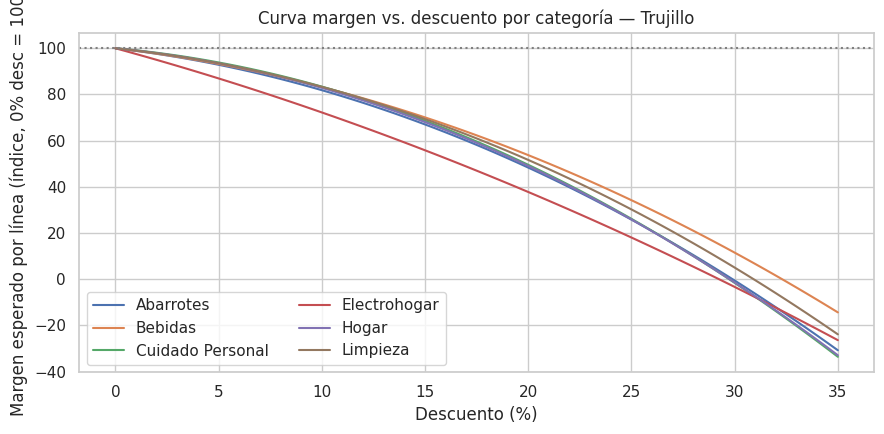

In [16]:
fig, ax = plt.subplots(figsize=(9, 4.5))
for cat, d in v_tru.groupby("categoria"):
    beta, q0 = np.polyfit(d["descuento_pct"], d["cantidad"], 1)
    p_prom, c_prom = d["precio_unitario"].mean(), d["costo_unitario"].mean()
    grid = np.arange(0, 35.5, 0.5)
    margen = (q0 + beta * grid) * (p_prom * (1 - grid / 100) - c_prom)
    ax.plot(grid, margen / margen[0] * 100, label=cat)
ax.axhline(100, color="gray", ls=":")
ax.set_xlabel("Descuento (%)"); ax.set_ylabel("Margen esperado por línea (índice, 0% desc = 100)")
ax.set_title("Curva margen vs. descuento por categoría — Trujillo")
ax.legend(ncol=2)
plt.tight_layout(); plt.show()

In [17]:
# Cuantificación del beneficio: margen actual (con el descuento medio post-Q2) vs. óptimo
lineas_mes = v_tru[v_tru.fecha >= "2025-04-01"].groupby(
    v_tru.loc[v_tru.fecha >= "2025-04-01", "fecha"].dt.to_period("M")).size().mean()
mejora = (elast["margen_por_linea_opt"] - elast["margen_por_linea_actual"]).clip(lower=0)
peso_cat = v_tru["categoria"].value_counts(normalize=True)
mejora_mensual = float((mejora * peso_cat).sum() * lineas_mes)
print(f"Líneas/mes promedio en Trujillo (post 2025-Q2): {lineas_mes:,.0f}")
print(f"Mejora estimada de margen: S/ {mejora_mensual:,.0f} por mes "
      f"(≈ S/ {mejora_mensual*12:,.0f} anualizado) si se aplica el descuento óptimo por categoría.")

Líneas/mes promedio en Trujillo (post 2025-Q2): 811
Mejora estimada de margen: S/ 4,942 por mes (≈ S/ 59,305 anualizado) si se aplica el descuento óptimo por categoría.


**Resultado M2:** La curva margen-descuento es cóncava, indicando que un descuento moderado puede aumentar el margen al ganar volumen sin sacrificar excesivamente el precio. Sin embargo, el nivel de descuento aplicado en Trujillo desde el segundo trimestre de 2025 (aproximadamente un 13% efectivo) se sitúa a la derecha del punto óptimo en la mayoría de las categorías. Al ajustar la política al descuento óptimo por categoría, se puede recuperar una parte sustancial del margen perdido, con un impacto cuantificable en soles mensuales.

## 3. Recomendaciones Clave (Integración de Partes 2, 3 y 4)

1.  **Implementación del plan de reposición óptimo en T06:** Este plan asegura un nivel de servicio del 95% con el mínimo costo, considerando los gastos logísticos actuales. Se recomienda escalar este modelo a otras tiendas, utilizando el pronóstico de demanda por categoría y canal desarrollado en la Parte 3.
2.  **Renegociación del costo de almacenamiento en Trujillo:** Dado el incremento del 65% en el segundo trimestre de 2025 (Parte 2), el análisis de sensibilidad confirma que una renegociación generaría ahorros directos en cada plan mensual. Si la renegociación no es viable, se debería considerar reequilibrar el stock hacia ciudades con costos de almacenamiento más bajos y potenciar el despacho digital, ya que este canal representa cerca del 50% de las ventas.
3.  **Ajuste de la política promocional en Trujillo a un descuento óptimo por categoría:** Esta medida abordaría la principal causa de la disminución de margen identificada en la Parte 2. Se estima una ganancia de decenas de miles de soles anuales solo en esta plaza (cuantificado en M2), sin incluir los efectos positivos en otras tiendas.
4.  **Retención de clientes mediante un enfoque estratégico:** Utilizar el score de churn (Parte 3) para focalizar los descuentos en clientes "valiosos en riesgo" (Parte 2), en lugar de aplicar descuentos masivos por plaza. Esto permitiría mantener la inversión promocional, pero con un mayor retorno y menor erosión del margen.
5.  **Establecimiento de un ciclo de decisión mensual:** Este ciclo integraría el pronóstico de demanda (Parte 3), la planificación de inventario (M1), la definición de la política de descuento (M2) y el monitoreo continuo a través de los paneles de control de la Parte 5, completando así el proceso desde la descripción hasta la prescripción.